In [4]:
import matplotlib.pyplot as plt
from functions import * # import functions from the .py file

from pylab import rcParams
rcParams["figure.figsize"] = 16, 4

PAYLOADSIZE = 14

if PAYLOADSIZE % 2 != 0:
    print("Alarm! the payload size is not even.")
NUM_16RND = (PAYLOADSIZE-2)//2 # how many 16 bits random number included in each frame
MAX_SEQ = 256 # (decimal) maximum seq number defined by the length of the seq, the length of seq is 1B

files = {
    50: "baseline-exp2/baseline2-50cm",
    100: "baseline-exp2/baseline2-100cm",
    150: "baseline-exp2/baseline2-150cm",
    200: "baseline-exp2/baseline2-200cm",
    250: "baseline-exp2/baseline2-250cm",
}

## Scatter: Seq nr vs BER

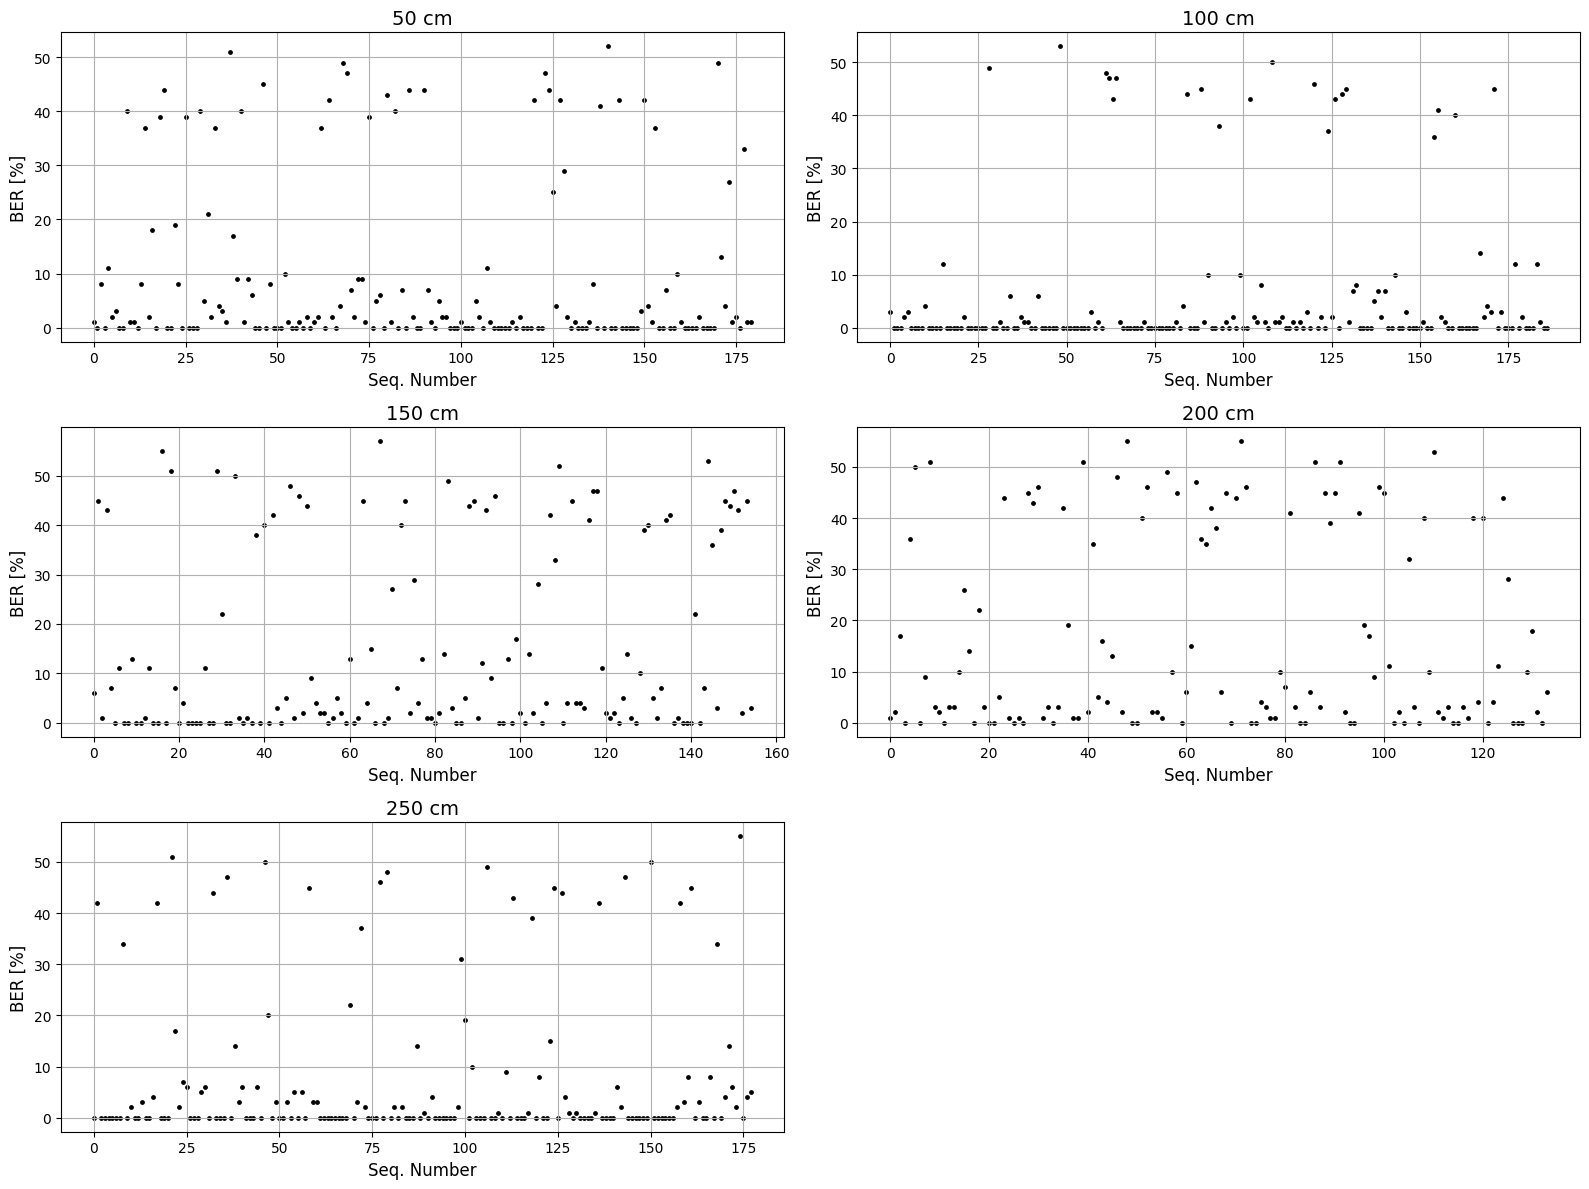

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12)) 
axes = axes.flatten()  

for ax, (dist, filename) in zip(axes, files.items()):
    df = readfile("./" + filename + ".csv")
    
    test = df[df.payload.apply(lambda x: len(x)==((PAYLOADSIZE)*3-1))]
    test.reset_index(inplace=True)

    ber_values = [
        compute_ber_packet(row, PACKET_LEN=NUM_16RND*2)[0]
        for _, row in test.iterrows()
    ]
    
    ax.scatter(range(len(test)), ber_values, s=6, color='black')
    ax.set_title(f"{dist} cm", fontsize=14)
    ax.set_ylabel("BER [%]", fontsize=12)
    ax.set_xlabel("Seq. Number", fontsize=12)
    ax.grid(True)

# remove unused subplot...
for i in range(len(files), len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Histogram: Seq nr vs BER

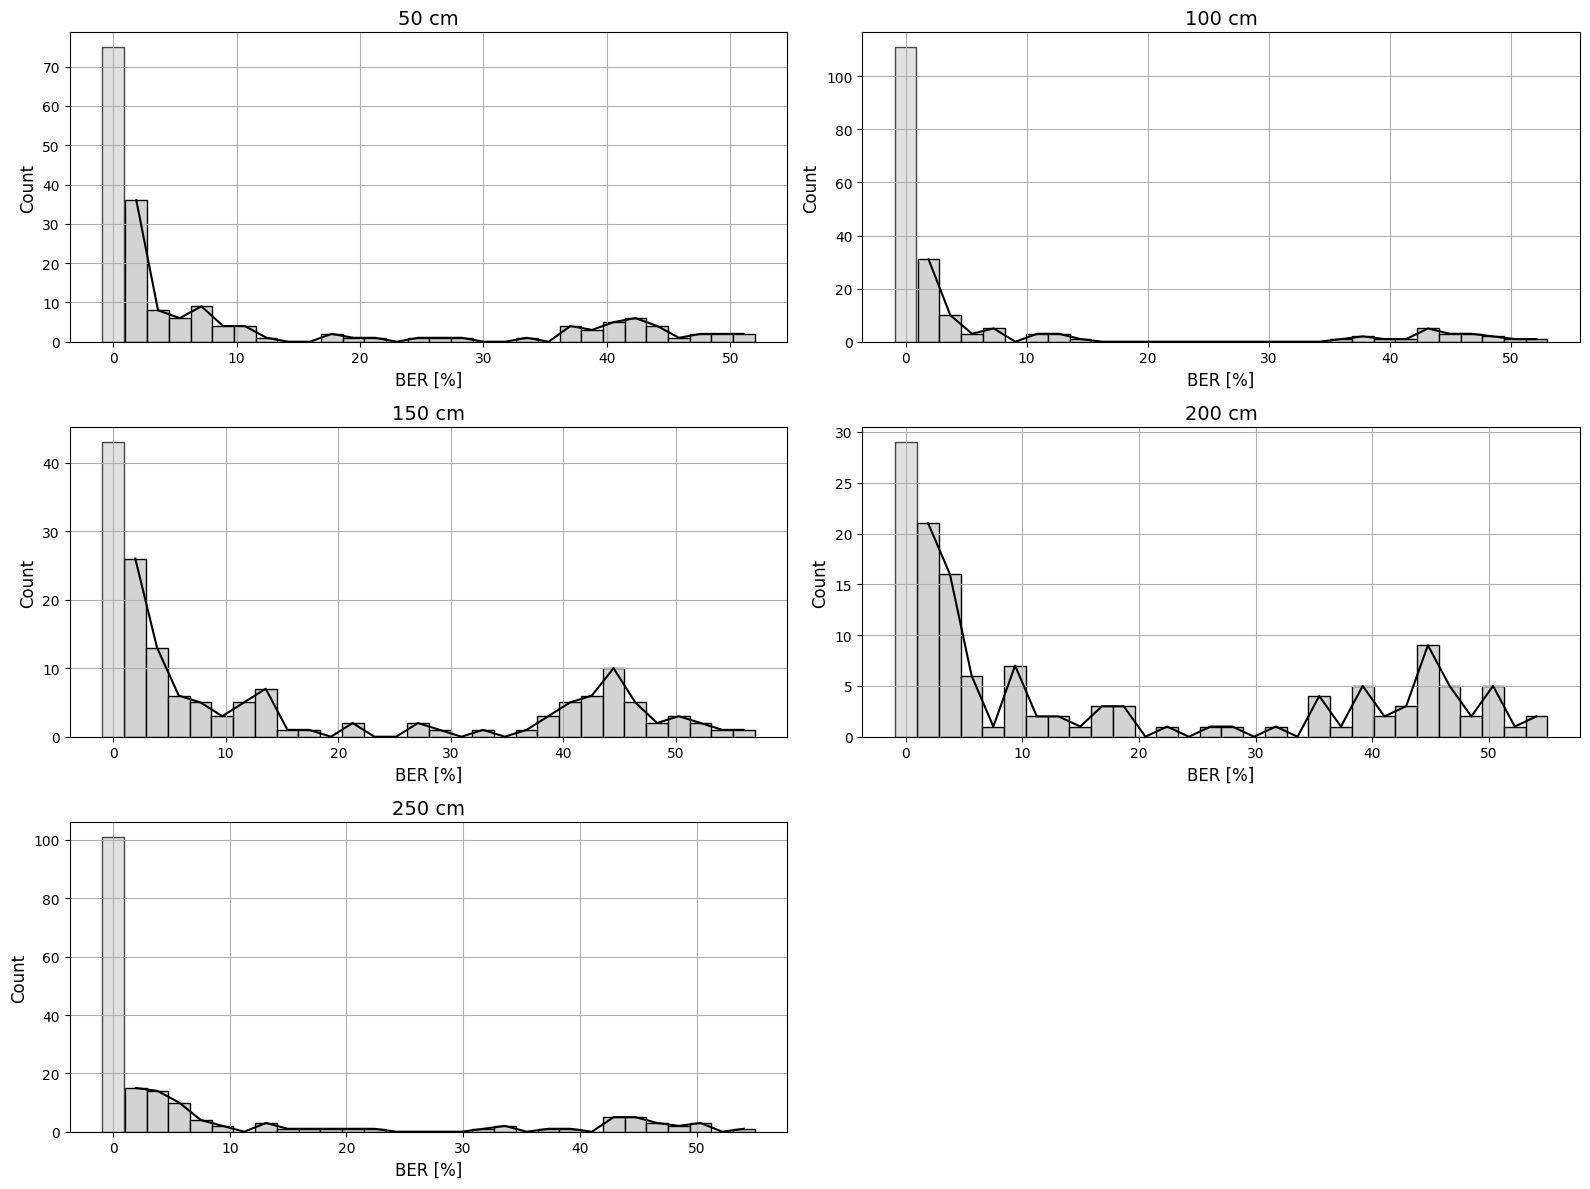

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12)) 
axes = axes.flatten()  

for ax, (dist, filename) in zip(axes, files.items()):
    df = readfile("./" + filename + ".csv")

    test = df[df.payload.apply(lambda x: len(x)==((PAYLOADSIZE)*3-1))]
    test.reset_index(inplace=True)

    ber_values = [
        compute_ber_packet(row, PACKET_LEN=NUM_16RND*2)[0]
        for _, row in test.iterrows()
    ]

    zeros = sum(1 for v in ber_values if v == 0)
    nonzero = [v for v in ber_values if v > 0]

    # plot histogram of nonzero values
    counts, bins, _ = ax.hist(nonzero, bins=29, color='lightgray', edgecolor='black')

    # manually add zero bin
    ax.bar(0, zeros, width=bins[1]-bins[0], color='lightgray', edgecolor='black', alpha=0.7)

    # Line on top (normalized or raw counts)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    ax.plot(bin_centers, counts, color='black', linewidth=1.5)

    ax.set_title(f"{dist} cm", fontsize=14)
    ax.set_xlabel("BER [%]", fontsize=12)
    ax.set_ylabel("Count", fontsize=12)
    ax.grid(True)

# remove unused subplot...
for i in range(len(files), len(axes)):
    axes[i].axis('off')
    
plt.tight_layout()
plt.show()